# M10 · Learning with Sparse & Implicit Labels — Hands-on, Step by Tiny Step

**Companion to lesson M10. Written for someone new to ML.**

Recommenders rarely get clean "like / dislike" labels. They get **implicit feedback**: a
click, a save, a brand contacting a creator. That's positive evidence — but a *missing*
click is **not** proof of dislike. Maybe the item was never shown, or buried at the bottom,
or the feedback just hasn't arrived yet. This notebook shows how to build honest training
data and honest metrics out of such messy signals.

**What you'll do (every step has an explanation, logging, and a picture):**
- **Part A · Implicit feedback & principled negatives:** why "unlabeled ≠ negative" (PU
  learning), how **negative sampling** makes training possible, the **uniform / popularity /
  hard** samplers and the **false-negative** risk, the **logQ** correction, and why
  **recall@k** depends on which candidates you test against.
- **Part B · Debiasing:** how **position bias** fools naive CTR, how **IPS** reweighting
  undoes it, why huge weights need **clipping** (a bias-variance tradeoff), and how
  **delayed feedback** makes fresh data look falsely negative.

We use **scikit-learn** + **matplotlib** (no installs in Colab). Run each cell with
**Shift+Enter**.

## Step 1 · Setup + a small helper

`rank_corr` measures how well two orderings agree (Spearman correlation, computed with plain
numpy). We'll use it to check whether a model's scores rank items in the *true* order.

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"

def rank_corr(a, b):
    ra = np.argsort(np.argsort(a)); rb = np.argsort(np.argsort(b))   # ranks
    return float(np.corrcoef(ra, rb)[0, 1])

print("ready")

ready


---
# Part A · Implicit feedback & principled negatives

## Step 2 · The core problem — "unlabeled ≠ negative" (PU learning)

Say a brand contacted **1** creator out of a catalog of **100,000**. The tempting move is to
call that 1 a positive and the other **99,999** negatives. But the brand never *saw* almost
any of them! Most are simply **unlabeled** — unknown, not disliked. Treating them all as
negatives teaches the model a lie. This is **PU learning**: **P**ositive + **U**nlabeled,
not positive + negative.

catalog: 100,000 creators
observed positives: 1
naive 'everything else is negative': 99,999 fake negatives
reality: those are UNLABELED (unseen / undecided / delayed), not confirmed dislikes


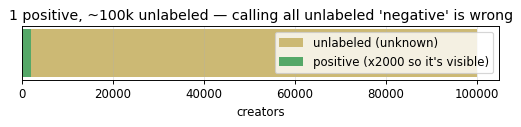

In [5]:
catalog = 100_000
positives = 1
print(f"catalog: {catalog:,} creators")
print(f"observed positives: {positives}")
print(f"naive 'everything else is negative': {catalog-positives:,} fake negatives")
print("reality: those are UNLABELED (unseen / undecided / delayed), not confirmed dislikes")
plt.figure(figsize=(6,1.6))
plt.barh([0],[catalog-positives], color=GOLD, label="unlabeled (unknown)")
plt.barh([0],[positives*2000], color=GREEN, label="positive (x2000 so it's visible)")
plt.yticks([]); plt.xlabel("creators"); plt.legend(loc="upper right")
plt.title("1 positive, ~100k unlabeled — calling all unlabeled 'negative' is wrong"); plt.show()

## Step 3 · Build a tiny brand→creator dataset (with a known truth)

To experiment we make synthetic data where **we** control the truth. Each brand and creator
gets a short hidden "taste vector"; their **true affinity** is the dot product. Observed
positives are high-affinity pairs (tilted by exposure/popularity, as in real logs). We hold
out one positive per brand as a test target.

In [7]:
rng = np.random.default_rng(3)
n_brands, n_creators, dim = 400, 1000, 6
Bf = rng.normal(0, 1, (n_brands, dim))     # brand taste vectors
Cf = rng.normal(0, 1, (n_creators, dim))   # creator style vectors
affinity = Bf @ Cf.T                        # TRUE affinity (hidden from the model)
pop = rng.zipf(1.5, n_creators).astype(float); pop = np.clip(pop, 1, 300); popn = pop / pop.sum()

positives = {}
for b in range(n_brands):
    a = affinity[b]; pr = np.exp(a - a.max()) * popn; pr /= pr.sum()   # affinity x exposure
    k = rng.integers(4, 9)
    positives[b] = list(rng.choice(n_creators, size=k, replace=False, p=pr))
train_pos = {b: v[:-1] for b, v in positives.items() if len(v) >= 2}
test_pos  = {b: v[-1]  for b, v in positives.items() if len(v) >= 2}
print(f"{n_brands} brands, {n_creators} creators")
print(f"observed positive pairs (train): {sum(len(v) for v in train_pos.values())}")
print(f"held-out test positives: {len(test_pos)} (one per brand)")
print("popularity is skewed: top creator is exposed", round(popn.max()/popn.min()), "x more than the rarest")

400 brands, 1000 creators
observed positive pairs (train): 1975
held-out test positives: 400 (one per brand)
popularity is skewed: top creator is exposed 300 x more than the rarest


## Step 4 · Negative sampling makes training possible

We can't train on 100k negatives per positive. Instead, for each positive we **sample a few**
unlabeled creators as stand-in negatives. The model here is deliberately simple: a linear
classifier on the **element-wise product** of the brand and creator vectors — summing that
product *is* the affinity, so a linear model can learn it. We evaluate with **recall@50**:
did the held-out true positive land in the model's top 50?

training rows: 11850 (positive rate 0.17) — balanced enough to learn
recall@50: model 0.535   vs   random 0.050   (11x better)


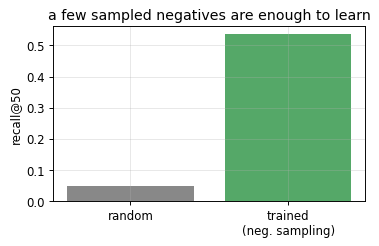

In [9]:
def pair_feat(bs, cs):
    return Bf[bs] * Cf[cs]                       # element-wise product

def build_training(sampler="uniform", n_neg=5, seed=1):
    r = np.random.default_rng(seed); Xb, Xc, Y = [], [], []
    q = popn if sampler == "popularity" else None
    for b, items in train_pos.items():
        for i in items:
            Xb.append(b); Xc.append(i); Y.append(1)                 # positive
            for j in r.choice(n_creators, n_neg, p=q):
                Xb.append(b); Xc.append(j); Y.append(0)             # sampled negative
    return np.array(Xb), np.array(Xc), np.array(Y)

def recall_at_k(model, k=50):
    hits = 0
    for b, ti in test_pos.items():
        s = model.decision_function(Bf[b] * Cf)                     # score ALL creators
        for i in train_pos[b]: s[i] = -1e9                          # exclude train positives
        topk = np.argpartition(-s, k)[:k]
        hits += int(ti in topk)
    return hits / len(test_pos)

Xb, Xc, Y = build_training("uniform")
model = LogisticRegression(max_iter=1000).fit(pair_feat(Xb, Xc), Y)
r_model = recall_at_k(model); r_random = 50 / n_creators
print(f"training rows: {len(Y)} (positive rate {Y.mean():.2f}) — balanced enough to learn")
print(f"recall@50: model {r_model:.3f}   vs   random {r_random:.3f}   ({r_model/r_random:.0f}x better)")
plt.figure(figsize=(4.5,3)); plt.bar(["random","trained\n(neg. sampling)"], [r_random, r_model], color=[GRAY, GREEN])
plt.ylabel("recall@50"); plt.title("a few sampled negatives are enough to learn"); plt.show()

## Step 5 · The sampler zoo — where do negatives come from?

Different samplers draw different "negatives," and the choice matters:

| Sampler | Draws from | Good for | Watch out |
|---|---|---|---|
| **Uniform** | catalog evenly | broad coverage | usually too easy |
| **Popularity** | exposure-weighted | realistic confusions | overweights head creators |
| **Hard** | items the model already scores high | fine distinctions | may be false negatives |

Let's *see* the difference: a histogram of how popular the sampled negatives are under
uniform vs popularity sampling.

uniform avg popularity of negatives:    32.2
popularity avg popularity of negatives: 214.8 (much higher — head-heavy)


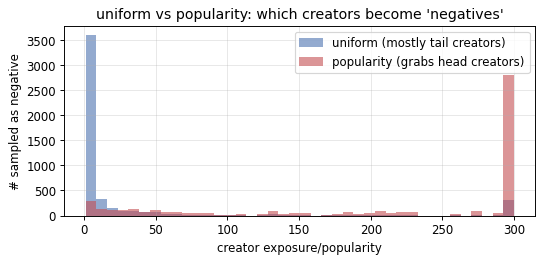

In [11]:
r = np.random.default_rng(0)
uni = r.choice(n_creators, 5000)                  # uniform negatives
pops = r.choice(n_creators, 5000, p=popn)          # popularity negatives
plt.figure(figsize=(6.5,3.2))
plt.hist(pop[uni],  bins=40, alpha=.6, color=BLUE,  label="uniform (mostly tail creators)")
plt.hist(pop[pops], bins=40, alpha=.6, color=RED,   label="popularity (grabs head creators)")
plt.xlabel("creator exposure/popularity"); plt.ylabel("# sampled as negative"); plt.legend()
plt.title("uniform vs popularity: which creators become 'negatives'"); plt.show()
print("uniform avg popularity of negatives:   ", round(pop[uni].mean(), 1))
print("popularity avg popularity of negatives:", round(pop[pops].mean(), 1), "(much higher — head-heavy)")

## Step 6 · Hard negatives are powerful but risky (false negatives)

**Hard negatives** are the creators the model *already* ranks high but that weren't contacted
— great for teaching fine distinctions. The danger: many are creators the brand *would*
actually love (true positives it just hasn't reached yet). Using them as negatives teaches
the model the wrong thing. We measure how often a hard negative is truly a top-20 match, vs a
uniform-random negative.

hard negatives that are actually top-20 matches:   0.38  (false-negative risk!)
uniform-random negatives that are top-20 matches:  0.021  (much safer)


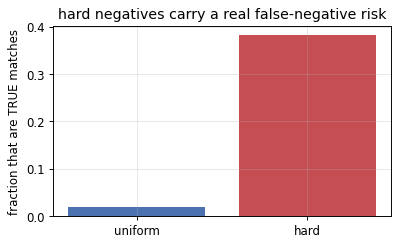

In [13]:
model_score = affinity + np.random.default_rng(3).normal(0, 2.0, affinity.shape)  # an imperfect model
fn_hard = tot_hard = fn_uni = tot_uni = 0
ru = np.random.default_rng(5)
for b in range(n_brands):
    true_top = set(np.argsort(-affinity[b])[:20].tolist())         # would-be strong matches
    contacted = set(np.argsort(-affinity[b])[:3].tolist())
    hard = [i for i in np.argsort(-model_score[b]) if i not in contacted][:10]
    for j in hard:            tot_hard += 1; fn_hard += int(j in true_top)
    for j in ru.choice(n_creators, 10, replace=False):
                              tot_uni  += 1; fn_uni  += int(j in true_top)
print(f"hard negatives that are actually top-20 matches:   {fn_hard/tot_hard:.2f}  (false-negative risk!)")
print(f"uniform-random negatives that are top-20 matches:  {fn_uni/tot_uni:.3f}  (much safer)")
plt.figure(figsize=(4.8,3)); plt.bar(["uniform","hard"], [fn_uni/tot_uni, fn_hard/tot_hard], color=[BLUE, RED])
plt.ylabel("fraction that are TRUE matches"); plt.title("hard negatives carry a real false-negative risk"); plt.show()

## Step 7 · logQ correction — don't punish an item for being sampled often

If you sample negatives by **popularity**, a head creator appears as a "negative" far more
often than a tail creator — purely because it's popular, not because it's bad. Left alone,
the model learns to **under-score popular items**. The **logQ correction** subtracts the log
sampling probability from each score, `s_i - log Q(i)`, cancelling that artificial frequency.

We show it on a clean **sampled-softmax** retrieval task: learn a score per item from
positives (drawn by true relevance) and negatives (drawn by popularity `Q`), with and without
the correction. We check (a) how well scores rank the true relevance and (b) whether the
score error is correlated with popularity (a bias we want at ~0).

In [15]:
rng2 = np.random.default_rng(0)
M = 200
z_true = rng2.normal(0, 1.2, M)                                   # true relevance (hidden)
p_true = np.exp(z_true - z_true.max()); p_true /= p_true.sum()
Q = rng2.zipf(1.4, M).astype(float); Q = np.clip(Q, 1, 500); Q /= Q.sum()   # popularity sampler

def train_sampled_softmax(correct, steps=4000, n_neg=20, lr=0.5):
    s = np.zeros(M)
    for t in range(steps):
        pos = rng2.choice(M, p=p_true)
        negs = rng2.choice(M, size=n_neg, p=Q)
        cand = np.append(negs, pos)
        logits = s[cand].copy()
        if correct:
            logits = logits - np.log(np.append(Q[negs], Q[pos]))  # <-- logQ correction
        logits -= logits.max()
        pr = np.exp(logits); pr /= pr.sum()
        g = pr.copy(); g[-1] -= 1                                  # softmax gradient (pos is last)
        np.add.at(s, cand, -lr * g / np.sqrt(t + 1))
    return s

for correct in [False, True]:
    s = train_sampled_softmax(correct)
    rho = rank_corr(s, z_true)
    bias = np.corrcoef(s - z_true, np.log(Q))[0, 1]               # error vs popularity (want ~0)
    tag = "WITH logQ" if correct else "no correction"
    print(f"{tag:14}: rank-corr with truth = {rho:.3f}   |  popularity bias = {bias:+.3f}")

no correction : rank-corr with truth = 0.663   |  popularity bias = -0.365
WITH logQ     : rank-corr with truth = 0.828   |  popularity bias = +0.089


no correction: popular items (right) are pushed DOWN (negative error). logQ removes the tilt.


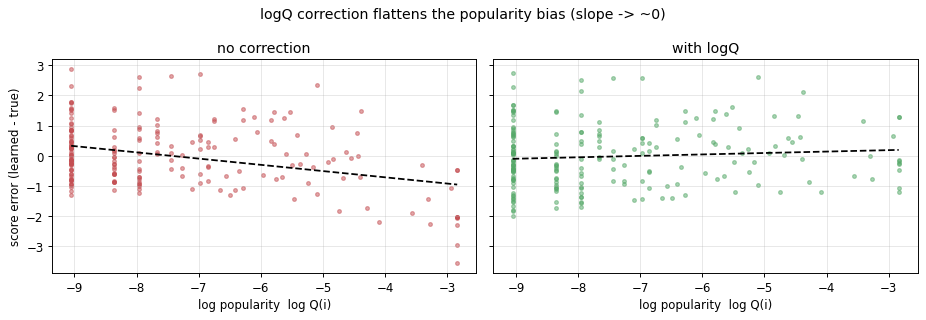

In [16]:
# visualize the popularity bias being removed
s_no  = train_sampled_softmax(False)
s_yes = train_sampled_softmax(True)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for a, s, name, c in [(ax[0], s_no, "no correction", RED), (ax[1], s_yes, "with logQ", GREEN)]:
    a.scatter(np.log(Q), s - z_true, s=10, alpha=.5, color=c)
    z = np.polyfit(np.log(Q), s - z_true, 1); xs = np.array([np.log(Q).min(), np.log(Q).max()])
    a.plot(xs, np.polyval(z, xs), "k--")
    a.set_xlabel("log popularity  log Q(i)"); a.set_title(name)
ax[0].set_ylabel("score error (learned - true)")
fig.suptitle("logQ correction flattens the popularity bias (slope -> ~0)"); plt.show()
print("no correction: popular items (right) are pushed DOWN (negative error). logQ removes the tilt.")

## Step 8 · recall@k has no meaning without saying the candidate universe

Without true negatives, **recall@k = "did we retrieve the known positives?"** — and the
answer depends entirely on **which candidates** you rank against. Testing against a handful
of easy sampled negatives looks great; testing against the full catalog is much harder.
Always state the universe.

In [18]:
def recall_universe(model, k=50, universe="full", seed=0):
    r = np.random.default_rng(seed); hits = 0
    for b, ti in test_pos.items():
        if universe == "full":
            cand = np.arange(n_creators)
        else:                                              # ti + a few sampled negatives
            cand = np.append(r.choice(n_creators, 200, replace=False), ti)
        s = model.decision_function(Bf[b] * Cf[cand])
        order = cand[np.argsort(-s)]
        hits += int(ti in order[:k])
    return hits / len(test_pos)

for uni in ["sampled (ti + 200)", "full"]:
    key = "full" if uni == "full" else "sampled"
    print(f"recall@50 vs {uni:18}: {recall_universe(model, universe=key):.3f}")
print("same model, very different numbers — report the candidate universe every time.")

recall@50 vs sampled (ti + 200): 0.877
recall@50 vs full              : 0.522
same model, very different numbers — report the candidate universe every time.


---
# Part B · Debiasing (position, selection, delayed)

## Step 9 · Observed labels are filtered, not random

The old system decides **what** gets shown and **where**. So the logs are biased:

| Bias | What happens | Failure |
|---|---|---|
| **Position** | top ranks get more attention | confuses *visibility* with *preference* |
| **Selection** | old policy picks what's observable | unshown items look invisible |
| **Delayed** | positives arrive late | fresh rows look falsely negative |

We'll demonstrate **position bias** and its fix (IPS), then **delayed feedback**.

## Step 10 · Position bias — identical items, different CTR

Set up five creators with the **exact same** true relevance (30% click *if examined*). But
each was mostly logged at a different rank, and higher ranks get examined more often
(propensities 0.8, 0.4, 0.2, 0.1, 0.05). Watch the **naive CTR** make them look wildly
different — even though they're identical.

  creator 1 @ rank 1 (propensity 0.80): naive CTR 0.242
  creator 2 @ rank 2 (propensity 0.40): naive CTR 0.122
  creator 3 @ rank 3 (propensity 0.20): naive CTR 0.060
  creator 4 @ rank 4 (propensity 0.10): naive CTR 0.029
  creator 5 @ rank 5 (propensity 0.05): naive CTR 0.015

naive CTR spans 0.015..0.242 — looks like a 16x difference, but they're identical!


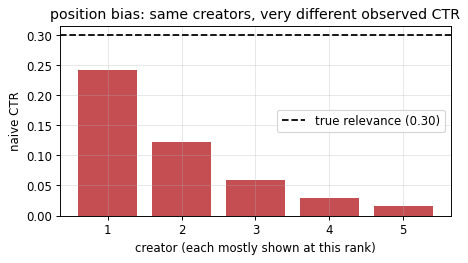

In [22]:
rng3 = np.random.default_rng(0)
exam = np.array([0.8, 0.4, 0.2, 0.1, 0.05])     # examination probability (propensity) by rank
true_rel = 0.30                                  # ALL five creators share this
n_imp = 40000
naive, ips = [], []
for pos in range(5):
    examined = rng3.random(n_imp) < exam[pos]
    clicked  = examined & (rng3.random(n_imp) < true_rel)
    naive.append(clicked.mean())                 # observed CTR (biased by position)
    ips.append((clicked / exam[pos]).mean())     # IPS: divide by propensity
for pos in range(5):
    print(f"  creator {pos+1} @ rank {pos+1} (propensity {exam[pos]:.2f}): naive CTR {naive[pos]:.3f}")
print(f"\nnaive CTR spans {min(naive):.3f}..{max(naive):.3f} — looks like a {max(naive)/min(naive):.0f}x difference, but they're identical!")
plt.figure(figsize=(5.5,3.2)); plt.bar(range(1,6), naive, color=RED)
plt.axhline(true_rel, color="k", ls="--", label="true relevance (0.30)")
plt.xlabel("creator (each mostly shown at this rank)"); plt.ylabel("naive CTR"); plt.legend()
plt.title("position bias: same creators, very different observed CTR"); plt.show()

## Step 11 · IPS undoes it — weight by 1 / propensity

**Inverse Propensity Scoring**: a click seen where exposure was unlikely counts for more.
Divide each outcome by the probability it was exposed:
$$\hat R_{IPS}=\frac1n\sum_i \frac{y_i}{\pi_i}.$$
A click at propensity 0.8 → weight 1.25; at 0.05 → weight 20. Applying it, all five creators
snap back to their true 0.30.

  rank 1: naive 0.242  ->  IPS 0.303  (weight for a click = 1.2)
  rank 2: naive 0.122  ->  IPS 0.304  (weight for a click = 2.5)
  rank 3: naive 0.060  ->  IPS 0.298  (weight for a click = 5.0)
  rank 4: naive 0.029  ->  IPS 0.293  (weight for a click = 10.0)
  rank 5: naive 0.015  ->  IPS 0.303  (weight for a click = 20.0)


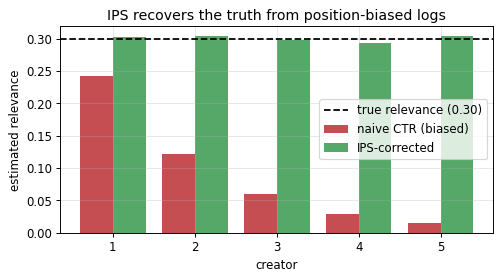

In [24]:
x = np.arange(1, 6)
plt.figure(figsize=(6,3.4))
plt.bar(x-0.2, naive, 0.4, color=RED,   label="naive CTR (biased)")
plt.bar(x+0.2, ips,   0.4, color=GREEN, label="IPS-corrected")
plt.axhline(true_rel, color="k", ls="--", label="true relevance (0.30)")
plt.xlabel("creator"); plt.ylabel("estimated relevance"); plt.legend()
plt.title("IPS recovers the truth from position-biased logs"); plt.show()
for pos in range(5):
    print(f"  rank {pos+1}: naive {naive[pos]:.3f}  ->  IPS {ips[pos]:.3f}  (weight for a click = {1/exam[pos]:.1f})")

## Step 12 · IPS variance & clipping — a bias-variance tradeoff

Those big weights (÷0.05 = ×20) are dangerous: one lucky click at a tiny propensity can
swing the estimate. **Clipping** caps the weight — this lowers variance but adds a little
bias. We estimate a creator's true 0.30 relevance over **600** simulated log-sets, unclipped
vs clipped, and compare the spread.

estimating true relevance 0.3 over 600 log-sets:
  unclipped : mean 0.293  std 0.056   (nearly unbiased, HIGH variance)
  clipped@5 : mean 0.259  std 0.027   (slight bias, LOW variance)


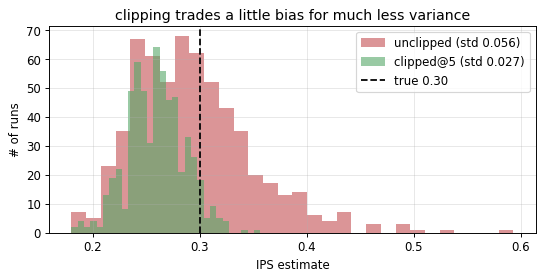

In [26]:
true_rel = 0.30
def one_run(seed, clip=None):
    r = np.random.default_rng(seed); n = 500
    prop = np.where(r.random(n) < 0.15, 0.03, 0.6)         # mostly 0.6, sometimes tiny 0.03
    click = ((r.random(n) < prop) & (r.random(n) < true_rel)).astype(float)
    w = 1 / prop
    if clip is not None: w = np.minimum(w, clip)
    return (w * click).mean()

unc = np.array([one_run(s)          for s in range(600)])
clp = np.array([one_run(s, clip=5)  for s in range(600)])
print(f"estimating true relevance {true_rel} over 600 log-sets:")
print(f"  unclipped : mean {unc.mean():.3f}  std {unc.std():.3f}   (nearly unbiased, HIGH variance)")
print(f"  clipped@5 : mean {clp.mean():.3f}  std {clp.std():.3f}   (slight bias, LOW variance)")
plt.figure(figsize=(6.5,3.4))
plt.hist(unc, bins=30, alpha=.6, color=RED,   label=f"unclipped (std {unc.std():.3f})")
plt.hist(clp, bins=30, alpha=.6, color=GREEN, label=f"clipped@5 (std {clp.std():.3f})")
plt.axvline(true_rel, color="k", ls="--", label="true 0.30")
plt.xlabel("IPS estimate"); plt.ylabel("# of runs"); plt.legend()
plt.title("clipping trades a little bias for much less variance"); plt.show()

## Step 13 · Delayed feedback — fresh rows look falsely negative

A brand may view a creator today and contact **next week**. If you snapshot labels too early,
recent rows look like "no contact" only because the contact **hasn't happened yet** — biasing
fresh cohorts downward. The fix (same as leakage in M2): score at exposure time, then **wait
for an attribution window** before using a row as a labeled negative.

1-day-old rows: observed 0.05 vs eventual 0.25  -> exclude immature rows or model the delay.


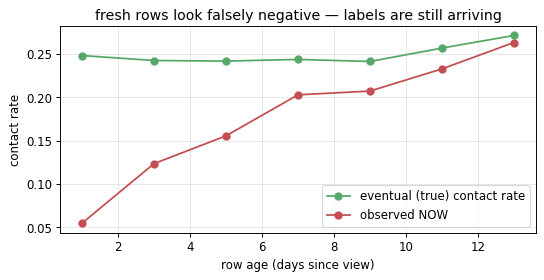

In [28]:
r = np.random.default_rng(7); K = 6000
age   = r.uniform(0, 14, K)              # days since the brand viewed the creator
will  = r.random(K) < 0.25              # 25% will EVENTUALLY contact
delay = r.exponential(4, K)             # contact arrives this many days after viewing
seen_now = will & (delay <= age)        # only counts if the contact already happened

bins = np.linspace(0, 14, 8); ctr = (bins[:-1] + bins[1:]) / 2
obs = [seen_now[(age >= lo) & (age < hi)].mean() for lo, hi in zip(bins[:-1], bins[1:])]
tru = [will[(age >= lo) & (age < hi)].mean()     for lo, hi in zip(bins[:-1], bins[1:])]
plt.figure(figsize=(6.5,3.4))
plt.plot(ctr, tru, "o-", color=GREEN, label="eventual (true) contact rate")
plt.plot(ctr, obs, "o-", color=RED,   label="observed NOW")
plt.xlabel("row age (days since view)"); plt.ylabel("contact rate"); plt.legend()
plt.title("fresh rows look falsely negative — labels are still arriving"); plt.show()
print(f"1-day-old rows: observed {obs[0]:.2f} vs eventual {tru[0]:.2f}  -> exclude immature rows or model the delay.")

---
## Recap — the M10 toolkit

**Implicit feedback & negatives (Part A).** A missing click is **unlabeled**, not negative
(**PU learning**). Make training feasible with **negative sampling**; pick the sampler on
purpose — **uniform** (easy, broad), **popularity** (realistic but head-heavy), **hard**
(sharp but ~1/3 can be **false negatives**). If you sample by popularity, apply the **logQ
correction** `s_i − log Q(i)` so frequently-sampled items aren't unfairly pushed down. And
**recall@k means nothing without naming the candidate universe.**

**Debiasing (Part B).** Logs are filtered by **position**, **selection**, and **delayed
feedback**. Position bias makes identical items look 16× apart; **IPS** (weight by
`1/propensity`) recovers the truth, but tiny propensities create huge weights, so **clip**
them (trading a little bias for much less variance). For delayed feedback, **wait for an
attribution window** before trusting a "no" — fresh rows look falsely negative.

**Where this connects:** M10 is how ranking systems (M7) learn from the messy labels reality
gives them. It reuses M8's calibration/delayed-feedback thinking and M9's careful handling of
sparse evidence — and its debiased, sampled training data is exactly what a production ranker
consumes.